# About Data

The sinking of the Titanic is one of the most infamous shipwrecks in history.

On April 15, 1912, during her maiden voyage, the widely considered “unsinkable” RMS Titanic sank after colliding with an iceberg. Unfortunately, there weren’t enough lifeboats for everyone on board, resulting in the death of 1502 out of 2224 passengers and crew.

While there was some element of luck involved in surviving, it seems some groups of people were more likely to survive than others.

# Data Dictionary

| Variable | Description |
|----------|-------------|
| survival |  0 = No, 1 = Yes |
| pclass |  1 = 1st, 2 = 2nd, 3 = 3rd |
| sibsp | Number of siblings / spouses aboard the Titanic |
| parch | Number of parents / children aboard the Titanic |
| embarked | Port of Embarkation: C = Cherbourg, Q = Queenstown, S = Southampton |

# 1. Import Libraries

In [261]:
import pandas as pd  
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

# 2. Load Data

In [262]:
df = pd.read_csv("titanic_dataset.csv")

# 3. Data Profiling

## 3.1 Shape

In [263]:
df.shape

(891, 12)

## 3.2 Column Names

In [264]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

## 3.3 Data Types

In [265]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

## 3.4 Head of Data

In [266]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### 3.5 Changing Data Types

In [267]:
c_col = ['Survived', 'Pclass', 'Sex', 'Parch', 'SibSp' , 'Embarked']

for c in c_col:
    df[c] = df[c].astype('category')

print("New Datatypes: ")
df.dtypes

New Datatypes: 


PassengerId       int64
Survived       category
Pclass         category
Name                str
Sex            category
Age             float64
SibSp          category
Parch          category
Ticket              str
Fare            float64
Cabin               str
Embarked       category
dtype: object

### 3.6 Duplicate Values

In [268]:
df.duplicated().sum()

np.int64(0)

### Conclusion:
1. This Data set have **891 Rows** and **12 Columns**.
2. This Data set have **No Duplicate Values**.
3. DataTypes of Few Columns have been changed to get better Insights from Data.
4. Now Data Types are catagorized as Following:
    - Numeric: [PassengerId, Age, Fare]
    - Categorical: [Survived, Pclass, Sex, Sibsp, Parch, Embarked]
    - Other: [Name, Ticket, Cabin]

# 4. Univarient Analysis 

## 4.1 Numerical Columns

- ###  Age :

In [269]:
df['Age'].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

<Axes: ylabel='Frequency'>

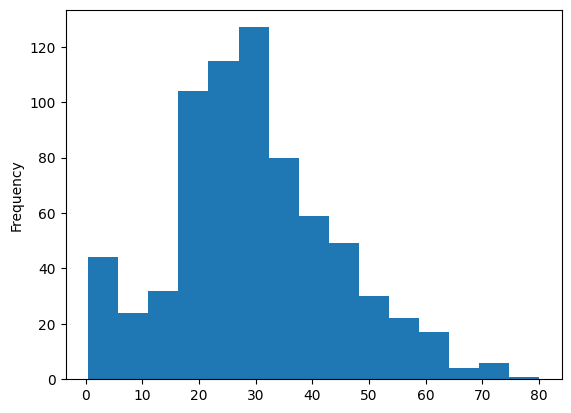

In [270]:
df['Age'].plot(kind='hist', bins=15)

<Axes: ylabel='Density'>

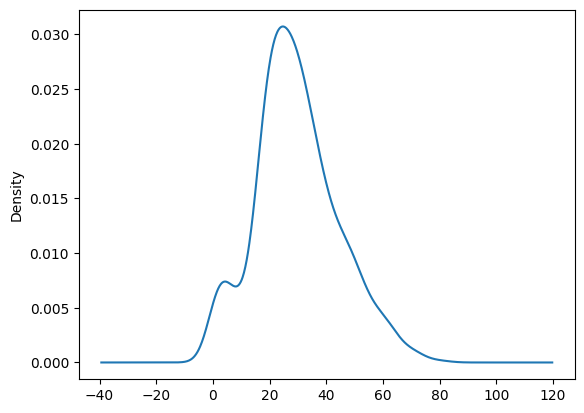

In [271]:
df['Age'].plot(kind='kde')

In [272]:
df['Age'].skew()

np.float64(0.38910778230082704)

In [273]:
df['Age'].isna().sum()

np.int64(177)

<Axes: >

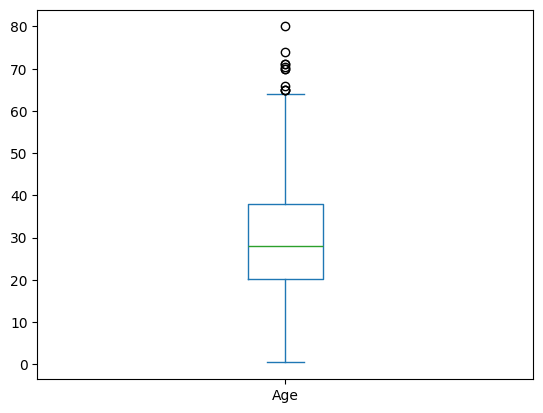

In [274]:
df['Age'].plot(kind='box')

In [275]:
df[df['Age'] > 65]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
33,34,0,2,"Wheadon, Mr. Edward H",male,66.0,0,0,C.A. 24579,10.5000,NaN,S
96,97,0,1,"Goldschmidt, Mr. George B",male,71.0,0,0,PC 17754,34.6542,A5,C
116,117,0,3,"Connors, Mr. Patrick",male,70.5,0,0,370369,7.7500,NaN,Q
493,494,0,1,"Artagaveytia, Mr. Ramon",male,71.0,0,0,PC 17609,49.5042,NaN,C
630,631,1,1,"Barkworth, Mr. Algernon Henry Wilson",male,80.0,0,0,27042,30.0000,A23,S
672,673,0,2,"Mitchell, Mr. Henry Michael",male,70.0,0,0,C.A. 24580,10.5000,NaN,S
745,746,0,1,"Crosby, Capt. Edward Gifford",male,70.0,1,1,WE/P 5735,71.0000,B22,S
851,852,0,3,"Svensson, Mr. Johan",male,74.0,0,0,347060,7.7750,NaN,S


__conclusions:__
- Age Column has **714** records.
- Age column  have **177** missing Values.
- Data in age Column is almost **Normally Skewed**.
- Skewness Value is **0.389**.
- Box Plot shows Data have some **Outliers** but when we analyze data these outliers we know that are not Invalid 

  - ### Fare :

In [276]:
df['Fare'].describe() 

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

<Axes: ylabel='Frequency'>

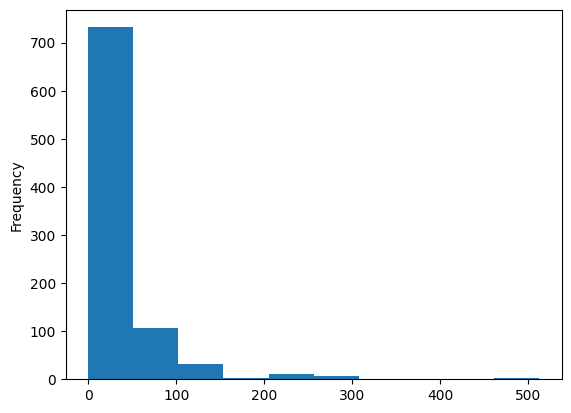

In [277]:
df['Fare'].plot(kind='hist')

<Axes: ylabel='Density'>

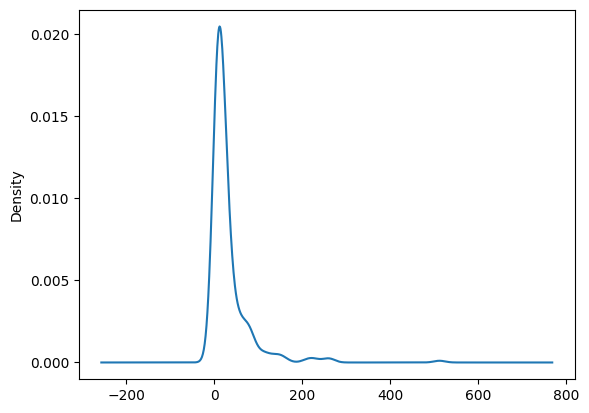

In [278]:
df['Fare'].plot(kind='kde')

In [279]:
df['Fare'].skew()

np.float64(4.787316519674893)

In [280]:
df['Fare'].isna().sum()

np.int64(0)

<Axes: >

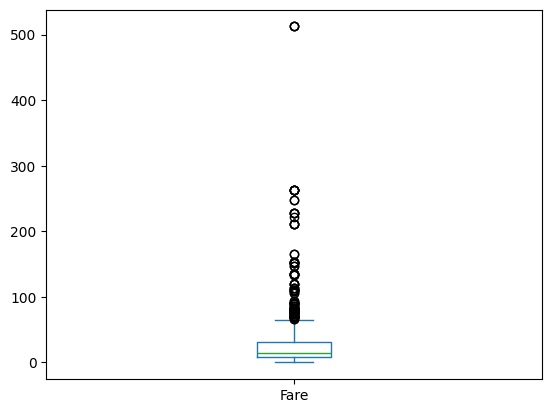

In [281]:
df["Fare"].plot(kind='box')

In [282]:
df['Fare']

0       7.2500
1      71.2833
2       7.9250
3      53.1000
4       8.0500
        ...   
886    13.0000
887    30.0000
888    23.4500
889    30.0000
890     7.7500
Name: Fare, Length: 891, dtype: float64

**Concloisions:**

- Fare have **891** Records.
- Fare have **NO Missing** Values.
- Data is **Highly Positive-skewed**.
- Skewness Value is **4.787**.
- Box plot shows many outliers due to:
    - Large Diffreence b/w Class 1,2 & 3 Tickets.
    - Right Skewed Data. 
- Fare Column Contains combined fare of whole family not individual person.

## 4.2 Categorical Columns

- # Survided :

In [283]:
df['Survived'].describe()

count     891
unique      2
top         0
freq      549
Name: Survived, dtype: int64

<Axes: xlabel='Survived'>

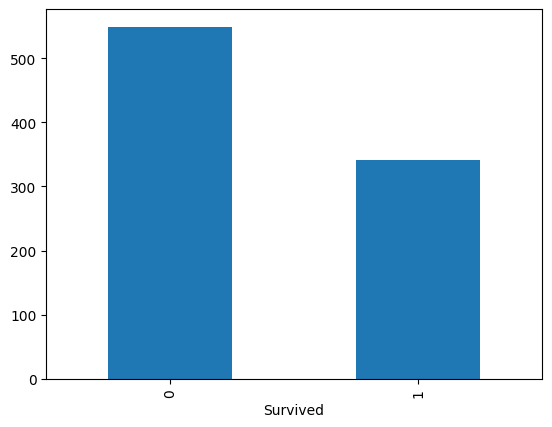

In [284]:
df['Survived'].value_counts().plot(kind='bar')

<Axes: >

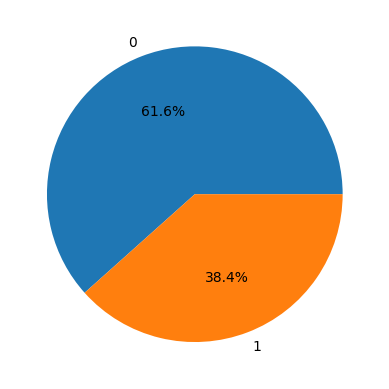

In [285]:
df['Survived'].value_counts().plot(kind='pie',autopct='%0.1f%%')

In [286]:
df['Survived'].isna().sum()

np.int64(0)

# Concollions:

- There are Total **891** Records
- No. of Passengers Passed > No. of  Passengers Survived. 
- About **61.6%** Passed and **38.4%** Survived.
- There are **NO MISSING** Values.

- ### Pclass :

In [287]:
df['Pclass'].describe()

count     891
unique      3
top         3
freq      491
Name: Pclass, dtype: int64

<Axes: xlabel='Pclass'>

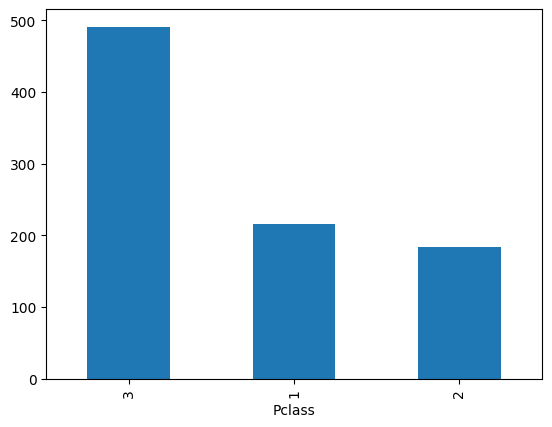

In [288]:
df['Pclass'].value_counts().plot(kind= 'bar')

<Axes: >

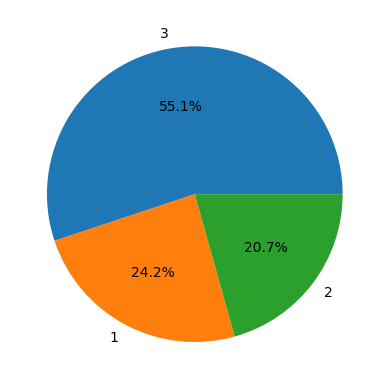

In [289]:
df['Pclass'].value_counts().plot(kind= 'pie',autopct = "%0.1f%%")

In [290]:
df['Pclass'].isna().sum()

np.int64(0)

# Concullions:

- Passengers distribution in Class is in following order: <br>
        **3rd Class > 1st Class > 2nd Class** <br>
        (55.1 %) > (24.2 %) > (20.7 %)
- There are **No MISSING** Values.
- There are Total **891** Records

- ### Sex :

In [291]:
df['Sex'].describe()

count      891
unique       2
top       male
freq       577
Name: Sex, dtype: object

<Axes: xlabel='Sex'>

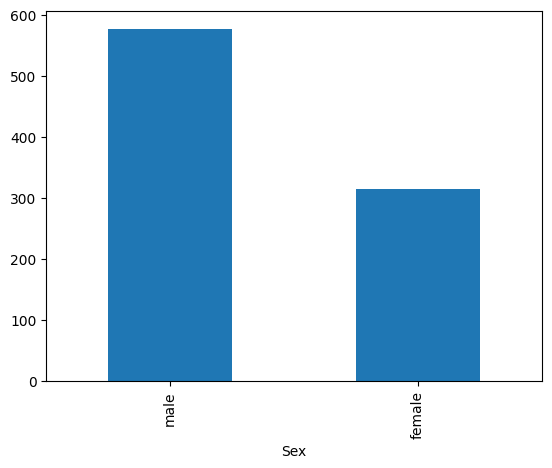

In [292]:
df['Sex'].value_counts().plot(kind='bar')

<Axes: >

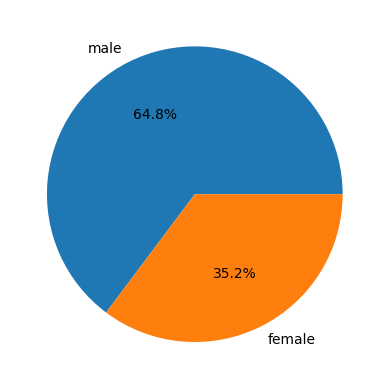

In [293]:
df['Sex'].value_counts().plot(kind='pie',autopct='%0.1f%%')


In [294]:
df['Sex'].isna().sum()

np.int64(0)

# Concullions
- There are **No MISSING** Values.
- There are Total **891** Records
- No. of **MALE Passengers >** No.of **FEMALE Passengers**.
- % of **Males**:   64.8 %
- % of **Females**: 35.2 %

- ### Parch :

In [295]:
df['Parch'].describe()

count     891
unique      7
top         0
freq      678
Name: Parch, dtype: int64

<Axes: xlabel='Parch'>

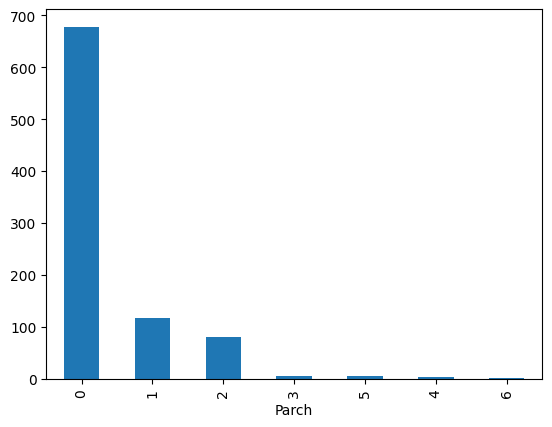

In [296]:
df['Parch'].value_counts().plot(kind = 'bar')

<Axes: >

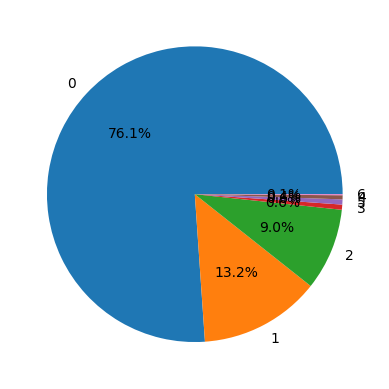

In [297]:
df['Parch'].value_counts().plot(kind = 'pie',autopct='%0.1f%%')

In [298]:
df['Parch'].isna().sum()

np.int64(0)

**Concollesion:**
- Data contains **891** Records.
- Data have **NO MISSING** Values.
- Majorty of People (76.1 %) were travelling withouts **Parents or Children**.

- ### Sibsp :

In [299]:
df['SibSp'].describe()

count     891
unique      7
top         0
freq      608
Name: SibSp, dtype: int64

<Axes: xlabel='SibSp'>

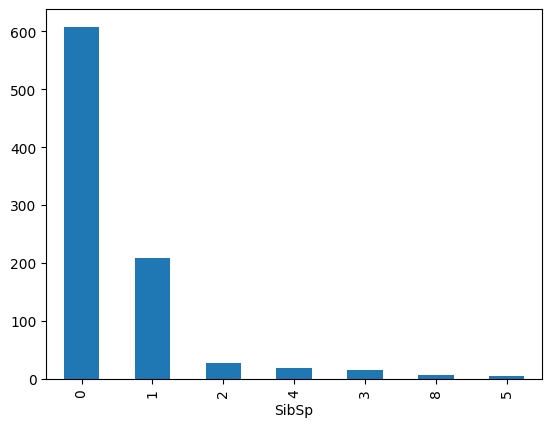

In [300]:
df['SibSp'].value_counts().plot(kind = 'bar')

<Axes: >

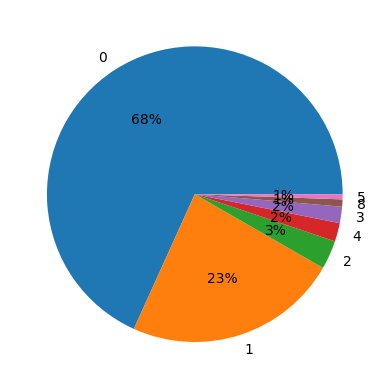

In [301]:
df['SibSp'].value_counts().plot(kind = 'pie', autopct='%0.0f%%')

In [302]:
df['SibSp'].isna().sum()

np.int64(0)

**Conculsions:**
- Majorty (68 %) were Trevelling without **Siblings and Supose**.
- There are total **891** Records.
- There are **NO MISSING** Values.


- ### Embarked :

In [303]:
df['Embarked'].describe()

count     889
unique      3
top         S
freq      644
Name: Embarked, dtype: object

<Axes: xlabel='Embarked'>

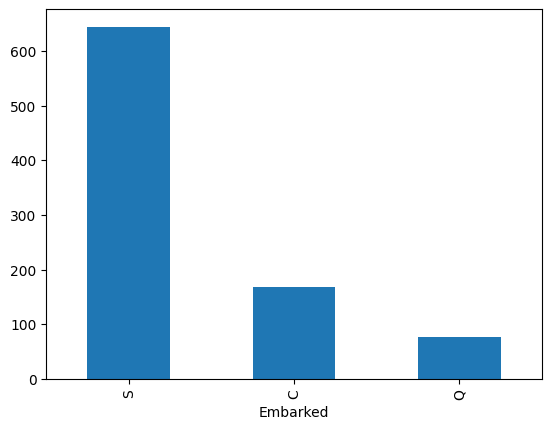

In [304]:
df['Embarked'].value_counts().plot(kind = 'bar')

<Axes: >

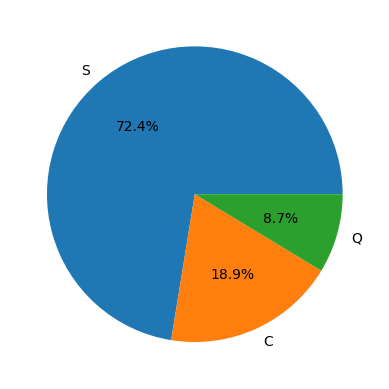

In [305]:
df['Embarked'].value_counts().plot(kind = 'pie',autopct='%0.01f%%')

In [306]:
df['Embarked'].isna().sum()

np.int64(2)

**Concullions**:
- There are total **889** Records.
- There are **2 Missing Values**.
- Most people (72.4 %) were board from S.
- Least people (8.7 %) were boarded from Q.

## 4.3 Other Columns

- ### Name :

In [307]:
df['Name']

0                                Braund, Mr. Owen Harris
1      Cumings, Mrs. John Bradley (Florence Briggs Th...
2                                 Heikkinen, Miss. Laina
3           Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                               Allen, Mr. William Henry
                             ...                        
886                                Montvila, Rev. Juozas
887                         Graham, Miss. Margaret Edith
888             Johnston, Miss. Catherine Helen "Carrie"
889                                Behr, Mr. Karl Howell
890                                  Dooley, Mr. Patrick
Name: Name, Length: 891, dtype: str

--> Surname

In [308]:
df['Surname'] = df['Name'].str.split(',').str[0]
df['Surname'] = df['Surname'].astype('category')

In [309]:
df['Surname'].describe()

count           891
unique          667
top       Andersson
freq              9
Name: Surname, dtype: object

In [310]:
df['Surname'].isna().sum()

np.int64(0)

--> Title

In [311]:
df['Title'] = df['Name'].str.split(',').str[1].str.split('.').str[0].str.strip()
df['Title'] = df["Title"].astype("category")


In [312]:
df['Title'].describe()

count     891
unique     17
top        Mr
freq      517
Name: Title, dtype: object

In [313]:
df['Title'].isna().sum()

np.int64(0)

<Axes: xlabel='Title'>

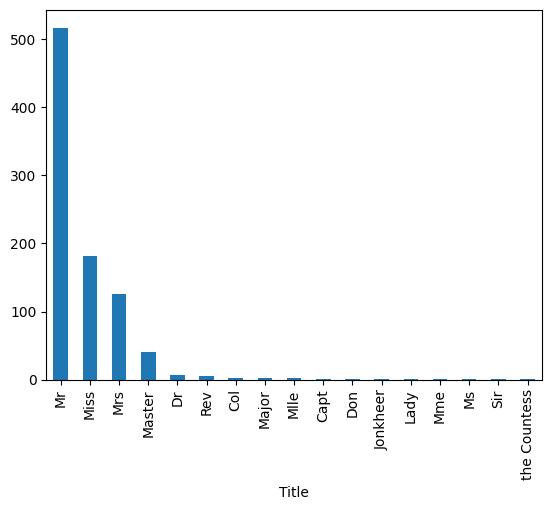

In [314]:
df['Title'].value_counts().plot(kind='bar')

**Conclusions:**
- We have Divided **Name** Column in **Title** & **Surname** columns.
- Both Column have **NO MISSING** Values.
- **Mr Title** is Most Frequently used.

- ### Cabin :

--> Deck

In [315]:
df['Deck'] = df['Cabin'].str[0]
df['Deck']

0      NaN
1        C
2      NaN
3        C
4      NaN
      ... 
886    NaN
887      B
888    NaN
889      C
890    NaN
Name: Deck, Length: 891, dtype: str

<Axes: xlabel='Deck'>

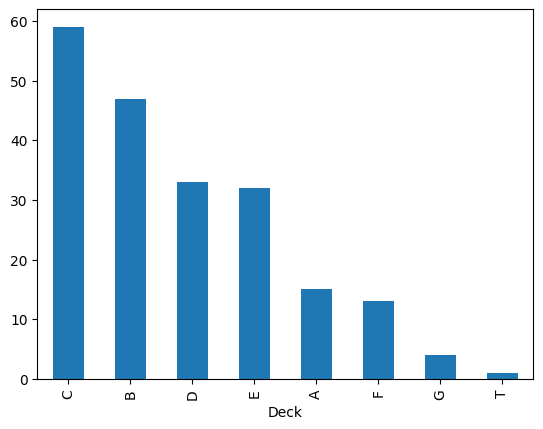

In [316]:
df['Deck'].value_counts().plot(kind='bar')

<Axes: >

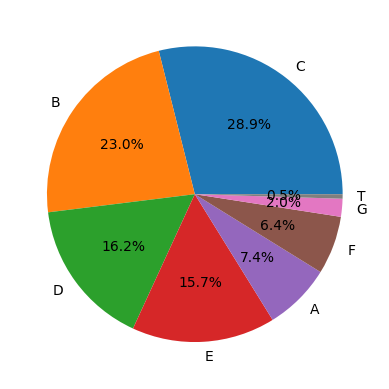

In [317]:
df['Deck'].value_counts().plot(kind='pie',autopct='%0.1f%%')

**Conculsions:**
- We have divided Cabin Column into **DECK** Column.
- Most people were treveling in **C Deck**.
- Least No. of people were treveling in **T Deck**.

- ### Ticket :

In [318]:
df['Ticket'].describe()

count        891
unique       681
top       347082
freq           7
Name: Ticket, dtype: object

**Conculions:** 
- There are Total **891** records.
- There are **NOMISSING** Values.
- There are **681** unique Tickets.

# 5. Bivarient Analysis:

# 5.1 Survived VS Sex

In [319]:
pd.crosstab(df['Survived'],df['Sex'],normalize = 'columns')* 100

Sex,female,male
Survived,,
0,25.796178,81.109185
1,74.203822,18.890815


<Axes: xlabel='Sex', ylabel='Survived'>

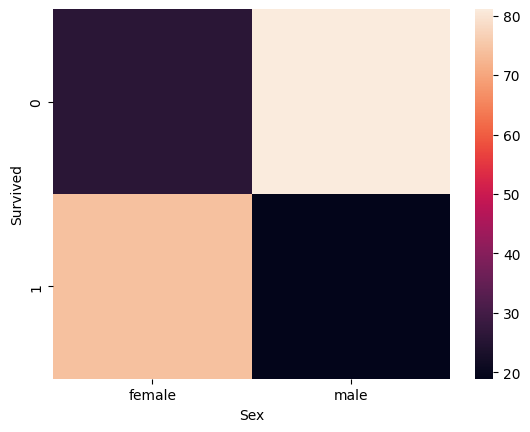

In [320]:
sns.heatmap(pd.crosstab(df['Survived'],df['Sex'],normalize='columns')*100)

**Conclusions:**
- No. of Females Survived > No. of Males Survived <br>
(74.3 %)                   >  (25.8 %)    
- No. of Males Died > No. of Females passed <br>
(81.1 %)                > (18.9 %)

# 5.2 Survived Vs Fare

<Axes: xlabel='Survived', ylabel='Fare'>

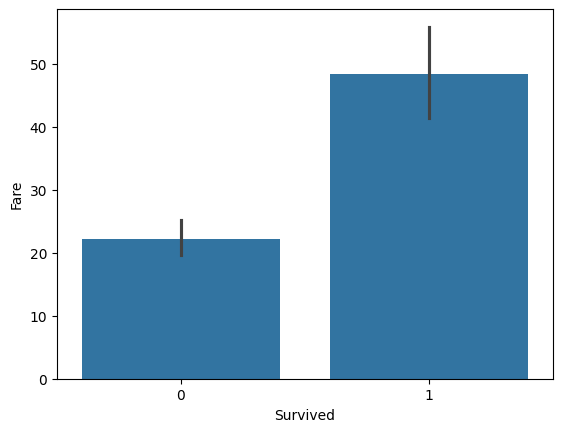

In [321]:
sns.barplot(data=df, x='Survived', y='Fare')

<Axes: xlabel='Fare', ylabel='Survived'>

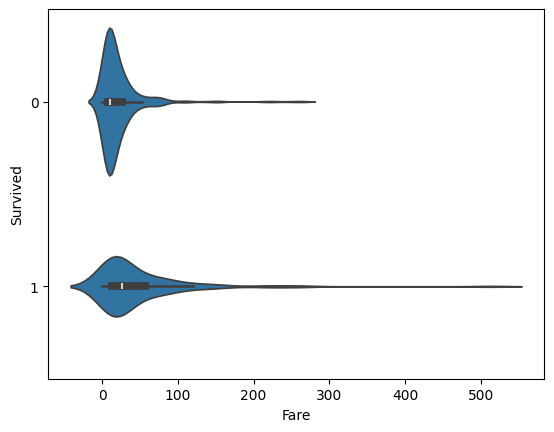

In [322]:
sns.violinplot(data=df, x='Fare', y='Survived')

**Concullions**:
- People who paid more had greater survival rate.

# 5.3 Survived VS Age

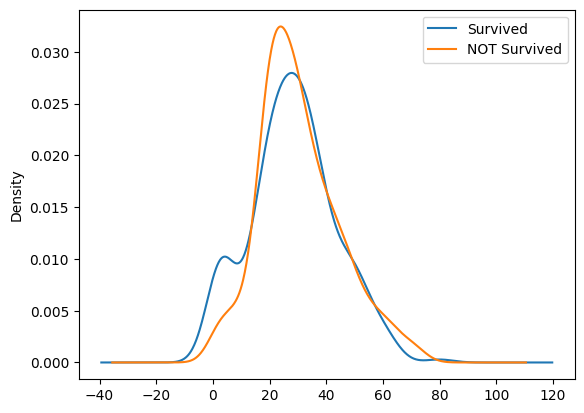

In [323]:
df[df['Survived'] == 1]['Age'].plot(kind='kde',label='Survived')
df[df['Survived'] == 0]['Age'].plot(kind='kde',label='NOT Survived')
plt.legend()
plt.show()

**Concullions:**
- Old Aged People have Low Survival Rate.
- Children and kids have high Survival Rate.

# 5.4 Survived VS Pclass

In [324]:
pd.crosstab(df['Pclass'],df['Survived'],normalize='columns')*100

Survived,0,1
Pclass,,
1,14.571949,39.766082
2,17.668488,25.438596
3,67.759563,34.795322


<Axes: xlabel='Survived', ylabel='Pclass'>

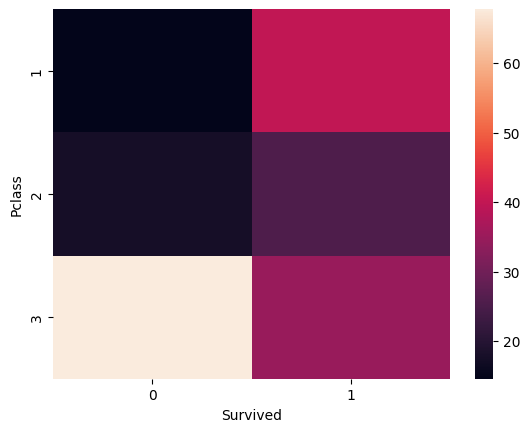

In [325]:
sns.heatmap(pd.crosstab(df['Pclass'],df['Survived'],normalize='columns')*100)

**Concullions:**
- 1st Class Passengers have **Highest** (39.7%) Survival Rate.
- 3rd Class Passengers have **Intermediate** (34.7) survival Rate.
- 2nd Class Passengers have **Lowest** (25.4 %)Survival Rate.

# 5.5 Survived VS Parch

In [326]:
pd.crosstab(df['Parch'],df['Survived'])

Survived,0,1
Parch,,
0,445,233
1,53,65
2,40,40
3,2,3
4,4,0
5,4,1
6,1,0


<Axes: xlabel='Parch', ylabel='Survived'>

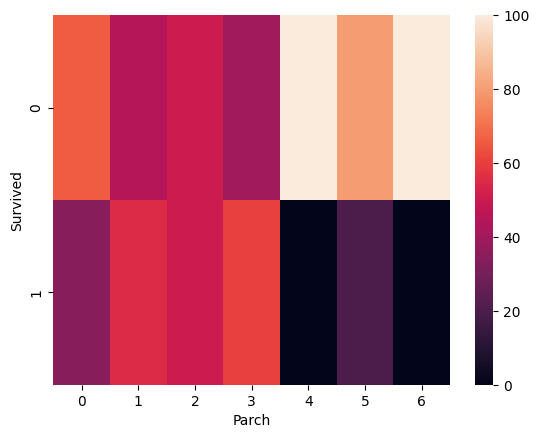

In [327]:
sns.heatmap(pd.crosstab(df['Survived'],df['Parch'],normalize='columns')*100)

**Concullions:**
- **445** people who were without parents or children died.
- **233** people who were without parents or children Survived.
- **40** People traveling with **2* Parents or children Survived.
- **4** person traveling with **4* parents or children died.
- **1** person traveling with **6* parents or children died.

# 5.6 Survived VS SibSp

In [328]:
pd.crosstab(df['SibSp'],df['Survived'])

Survived,0,1
SibSp,,
0,398,210
1,97,112
2,15,13
3,12,4
4,15,3
5,5,0
8,7,0


<Axes: xlabel='Parch', ylabel='Survived'>

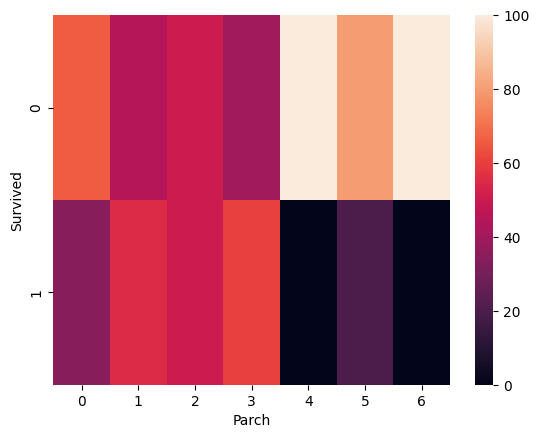

In [329]:
sns.heatmap(pd.crosstab(df['Survived'],df['Parch'], normalize='columns')* 100)

# 5.7 Survived VS Embarked  

In [330]:
pd.crosstab(df['Survived'],df['Embarked'] ,normalize='columns')*100

Embarked,C,Q,S
Survived,,,
0,44.642857,61.038961,66.304348
1,55.357143,38.961039,33.695652


<Axes: xlabel='Embarked', ylabel='Survived'>

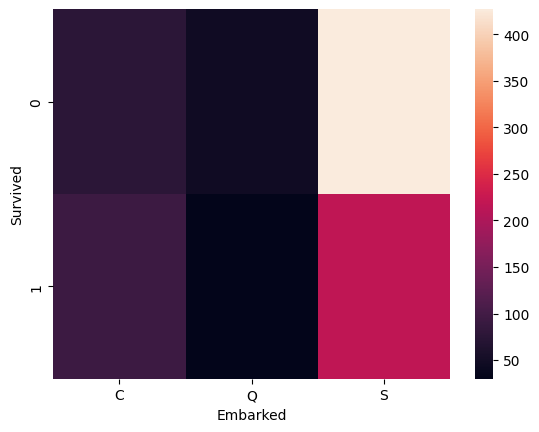

In [331]:
sns.heatmap(pd.crosstab(df['Survived'],df['Embarked']))

**Concullions:**
- People who were boarded from **C** Survived most.
- People who were boarded from **S** Died most.  

# 5.8 Survived VS Title

In [332]:
pd.crosstab(df['Survived'],df['Title'],normalize='columns')*100

Title,Capt,Col,Don,Dr,Jonkheer,Lady,Major,Master,Miss,Mlle,Mme,Mr,Mrs,Ms,Rev,Sir,the Countess
Survived,,,,,,,,,,,,,,,,,
0,100.0,50.0,100.0,57.142857,100.0,0.0,50.0,42.5,30.21978,0.0,0.0,84.332689,20.8,0.0,100.0,0.0,0.0
1,0.0,50.0,0.0,42.857143,0.0,100.0,50.0,57.5,69.78022,100.0,100.0,15.667311,79.2,100.0,0.0,100.0,100.0


# 5.9 Survived VS Deck

In [333]:
pd.crosstab(df['Survived'],df['Deck'],normalize='columns')*100

Deck,A,B,C,D,E,F,G,T
Survived,,,,,,,,
0,53.333333,25.531915,40.677966,24.242424,25.0,38.461538,50.0,100.0
1,46.666667,74.468085,59.322034,75.757576,75.0,61.538462,50.0,0.0


<Axes: xlabel='Deck', ylabel='Survived'>

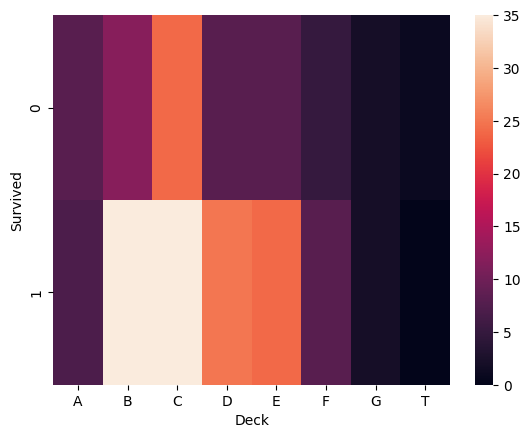

In [334]:
sns.heatmap(pd.crosstab(df['Survived'],df['Deck']))

**Concullions:**
- Most People (53.33%) Died on **DECK A**.
- On **Deck G** 50% died and 50% survived.
- On **Deck T** 100% died.

# 5.10 Pclass VS Sex

In [335]:
pd.crosstab(df['Sex'],df['Pclass'],normalize='columns')*100

Pclass,1,2,3
Sex,,,
female,43.518519,41.304348,29.327902
male,56.481481,58.695652,70.672098


<Axes: xlabel='Pclass', ylabel='Sex'>

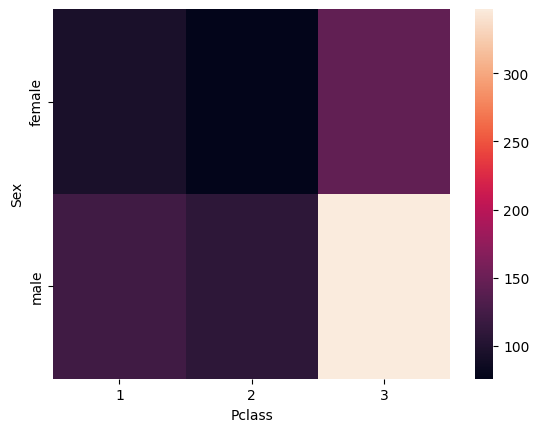

In [336]:
sns.heatmap(pd.crosstab(df['Sex'],df['Pclass']))

**Concullions:**
- Most Females (43.5%) Travelled in 1st Class.
- Most Males (70%) Travelled in 3rd Class.
- Least Females (29.3%) Travelled in 3rd Class.
- Least Males (56.5%) Travelled in 1st Class.

# 5.11 Age Vs Sex

<Axes: xlabel='Sex', ylabel='Age'>

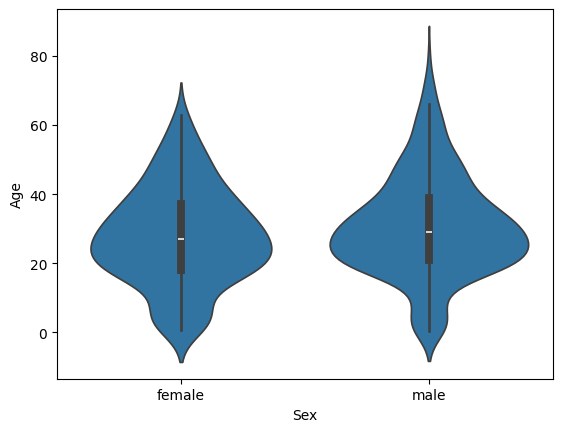

In [337]:
sns.violinplot(data=df, x='Sex', y='Age')

**Concullion:**
- Male Ages are more Distributed than Females.

# 6. Multivarient Analsysis

## 6.1 Co-relation

In [338]:
corr = df.corr(numeric_only=True)
corr

,PassengerId,Age,Fare
PassengerId,1.000000,0.036847,0.012658
Age,0.036847,1.000000,0.096067
Fare,0.012658,0.096067,1.000000


<Axes: >

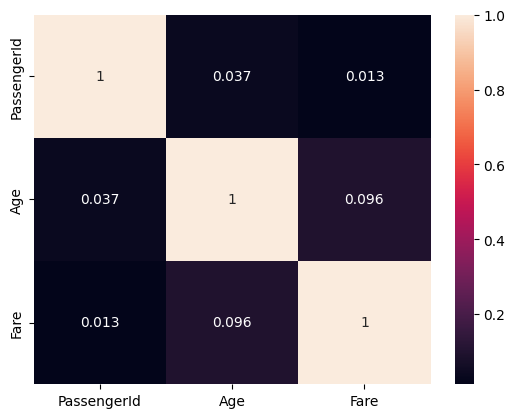

In [339]:
sns.heatmap(corr, annot=True)

**Concullions:**
- PassengerId doesn’t relate to Age or Fare.
- Age and Fare have vrey small positive relationship.



## 6.2 Sex VS Pclass VS Survived

In [340]:
pd.crosstab(
    [df['Sex'], df['Pclass']],
    df['Survived']
)

Survived         0   1
Sex    Pclass         
female 1         3  91
       2         6  70
       3        72  72
male   1        77  45
       2        91  17
       3       300  47

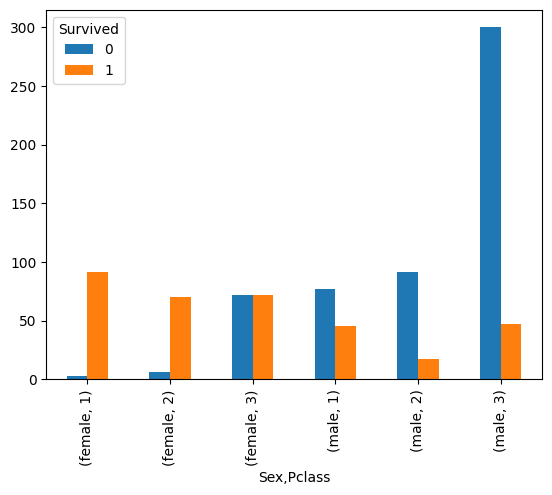

In [341]:
pd.crosstab(
    [df['Sex'], df['Pclass']],
    df['Survived']
).plot(kind='bar')

plt.show()

**Concullions:**
- Most Males (300) died in **3rd class**
- Most Females (71) died in **3rd class**